# Scikit-learn Baseline Modeling and Evaluation

This notebook documents the Version 1 Scikit-learn baseline workflow for financial complaint product classification.

- Week 5: build the first TF-IDF + Logistic Regression baseline.
- Week 6: compare Logistic Regression, Multinomial Naive Bayes, and Linear SVM.
- Week 7: evaluate the selected TF-IDF + Linear SVM model with aggregate outputs.

Guardrails: use only the cleaned 2024 model-development data, do not use the 2025 holdout dataset, do not show raw complaint narratives, and do not claim production readiness or final model selection.

## Week 5: TF-IDF + Logistic Regression Baseline

Week 5 builds the first working baseline only; confusion matrix visuals and saved model artifacts are added later in Week 7.

## 1. Imports and Project Paths

In [22]:
from pathlib import Path

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [23]:
def find_project_root(start_path):
    """Find the project root from either the repository root or the notebooks folder."""
    current_path = start_path.resolve()
    for candidate_path in [current_path, *current_path.parents]:
        expected_data_path = candidate_path / "data" / "processed" / "cfpb_complaints_2024_cleaned.csv"
        if expected_data_path.exists():
            return candidate_path
    raise FileNotFoundError("Could not find data/processed/cfpb_complaints_2024_cleaned.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cfpb_complaints_2024_cleaned.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH.relative_to(PROJECT_ROOT)}")

Project root: E:\MGA\ITEC6740\Final-Project\financial-complaint-auto-routing-nlp
Dataset path: data\processed\cfpb_complaints_2024_cleaned.csv


## 2. Load Cleaned 2024 Modeling Dataset

In [24]:
df = pd.read_csv(DATA_PATH)

print(f"Loaded rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Loaded rows: 50,000
Columns: ['clean_complaint_text', 'product']


In [25]:
required_columns = ["clean_complaint_text", "product"]
missing_required_columns = [column for column in required_columns if column not in df.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

print(f"Required columns present: {required_columns}")

Required columns present: ['clean_complaint_text', 'product']


## 3. Modeling Scope and Class Distribution

In [26]:
X = df["clean_complaint_text"].fillna("").astype(str)
y = df["product"]

class_counts = y.value_counts().rename_axis("product").reset_index(name="count")
minimum_class_count = 500

selected_class_counts = class_counts[class_counts["count"] >= minimum_class_count].copy()
excluded_class_counts = class_counts[class_counts["count"] < minimum_class_count].copy()
selected_classes = selected_class_counts["product"].tolist()

print("Week 5 Version 1 baseline scope: classes with at least 500 complaints.")
print("This is the first baseline modeling scope, not final model selection.")
print(f"Selected classes: {len(selected_classes)}")
print(selected_class_counts.to_string(index=False))

print("\nExcluded low-count classes for this first baseline scope:")
print(excluded_class_counts.to_string(index=False))

Week 5 Version 1 baseline scope: classes with at least 500 complaints.
This is the first baseline modeling scope, not final model selection.
Selected classes: 8
                                            product  count
Credit reporting or other personal consumer reports  36128
                                    Debt collection   5357
                                        Credit card   2735
                        Checking or savings account   2146
                                           Mortgage    887
 Money transfer, virtual currency, or money service    725
                                       Student loan    628
                              Vehicle loan or lease    590

Excluded low-count classes for this first baseline scope:
                                                product  count
Payday loan, title loan, personal loan, or advance loan    363
                                           Prepaid card    317
                              Debt or credit management    1

In [27]:
modeling_df = df[df["product"].isin(selected_classes)].copy()

X_model = modeling_df["clean_complaint_text"].fillna("").astype(str)
y_model = modeling_df["product"]

print(f"Rows before filtering: {len(df):,}")
print(f"Rows used for Week 5 baseline: {len(modeling_df):,}")
print(f"Rows excluded by low-count class filter: {len(df) - len(modeling_df):,}")
print(f"Product classes used: {y_model.nunique():,}")

Rows before filtering: 50,000
Rows used for Week 5 baseline: 49,196
Rows excluded by low-count class filter: 804
Product classes used: 8


## 4. Train/Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print("Stratified split used to preserve product category distribution.")

Training rows: 39,356
Test rows: 9,840
Stratified split used to preserve product category distribution.


## 5. TF-IDF + Logistic Regression Pipeline

In [29]:
baseline_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

print("Pipeline summary:")
print("- TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)")
print('- LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)')
print("This is a first baseline model, not a final model selection.")

Pipeline summary:
- TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
- LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
This is a first baseline model, not a final model selection.


## 6. Baseline Training

In [30]:
baseline_pipeline.fit(X_train, y_train)

print("Baseline model training complete.")

Baseline model training complete.


## 7. Test Set Evaluation

In [31]:
y_pred = baseline_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

metrics_table = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_precision",
            "weighted_recall",
            "weighted_f1",
        ],
        "value": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_precision,
            weighted_recall,
            weighted_f1,
        ],
    }
)
metrics_table["value"] = metrics_table["value"].round(4)

print(metrics_table.to_string(index=False))

            metric  value
          accuracy 0.8622
   macro_precision 0.6809
      macro_recall 0.8101
          macro_f1 0.7344
weighted_precision 0.8885
   weighted_recall 0.8622
       weighted_f1 0.8703


In [32]:
classification_metrics = classification_report(
    y_test,
    y_pred,
    labels=selected_classes,
    output_dict=True,
    zero_division=0,
)

per_class_metrics = (
    pd.DataFrame(classification_metrics)
    .transpose()
    .loc[selected_classes, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1"})
)
per_class_metrics[["precision", "recall", "f1"]] = per_class_metrics[["precision", "recall", "f1"]].round(4)
per_class_metrics["support"] = per_class_metrics["support"].astype(int)

print(per_class_metrics.to_string())

                                                     precision  recall      f1  support
Credit reporting or other personal consumer reports     0.9754  0.8778  0.9240     7226
Debt collection                                         0.6384  0.8433  0.7267     1072
Credit card                                             0.6048  0.8227  0.6971      547
Checking or savings account                             0.7434  0.7902  0.7661      429
Mortgage                                                0.7624  0.8701  0.8127      177
Money transfer, virtual currency, or money service      0.6306  0.6828  0.6556      145
Student loan                                            0.6488  0.8651  0.7415      126
Vehicle loan or lease                                   0.4433  0.7288  0.5513      118


## 8. Week 5 Summary

The Week 5 baseline uses the cleaned 2024 modeling dataset and keeps product classes with at least 500 complaints. It establishes TF-IDF + Logistic Regression as the first working baseline for this imbalanced Version 1 scope.

## Week 6: Compare Scikit-learn Baseline Classifiers

Using the same cleaned 2024 data, product-class scope, TF-IDF settings, and stratified split from Week 5, this section compares Logistic Regression, Multinomial Naive Bayes, and Linear SVM.

Selection is based only on their internal 2024 test-split results.

In [33]:
model_pipelines = {
    "TF-IDF + Logistic Regression": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=50000,
                    ngram_range=(1, 2),
                    min_df=2,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "TF-IDF + Multinomial Naive Bayes": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=50000,
                    ngram_range=(1, 2),
                    min_df=2,
                ),
            ),
            ("classifier", MultinomialNB()),
        ]
    ),
    "TF-IDF + Linear SVM": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=50000,
                    ngram_range=(1, 2),
                    min_df=2,
                ),
            ),
            (
                "classifier",
                LinearSVC(
                    random_state=42,
                    class_weight="balanced",
                    max_iter=10000,
                ),
            ),
        ]
    ),
}

print("Week 6 model comparison setup:")
print(f"- Models compared: {len(model_pipelines)}")
print(f"- Rows used: {len(X_model):,}")
print(f"- Training rows: {len(X_train):,}")
print(f"- Test rows: {len(X_test):,}")
print(f"- Product classes: {y_model.nunique():,}")
print("- TF-IDF settings: max_features=50000, ngram_range=(1, 2), min_df=2")
print("- Split: test_size=0.20, random_state=42, stratify=y")
print("- 2025 holdout dataset is not loaded or used.")

Week 6 model comparison setup:
- Models compared: 3
- Rows used: 49,196
- Training rows: 39,356
- Test rows: 9,840
- Product classes: 8
- TF-IDF settings: max_features=50000, ngram_range=(1, 2), min_df=2
- Split: test_size=0.20, random_state=42, stratify=y
- 2025 holdout dataset is not loaded or used.


In [34]:
comparison_results = []

for model_name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    model_predictions = pipeline.predict(X_test)

    model_accuracy = accuracy_score(y_test, model_predictions)
    model_macro_precision, model_macro_recall, model_macro_f1, _ = precision_recall_fscore_support(
        y_test,
        model_predictions,
        average="macro",
        zero_division=0,
    )
    model_weighted_precision, model_weighted_recall, model_weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        model_predictions,
        average="weighted",
        zero_division=0,
    )

    comparison_results.append(
        {
            "model": model_name,
            "accuracy": model_accuracy,
            "macro_precision": model_macro_precision,
            "macro_recall": model_macro_recall,
            "macro_f1": model_macro_f1,
            "weighted_precision": model_weighted_precision,
            "weighted_recall": model_weighted_recall,
            "weighted_f1": model_weighted_f1,
        }
    )

model_comparison = pd.DataFrame(comparison_results)
metric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
]
model_comparison[metric_columns] = model_comparison[metric_columns].round(4)
model_comparison

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,TF-IDF + Logistic Regression,0.8622,0.6809,0.8101,0.7344,0.8885,0.8622,0.8703
1,TF-IDF + Multinomial Naive Bayes,0.8513,0.8486,0.4025,0.4008,0.8637,0.8513,0.8302
2,TF-IDF + Linear SVM,0.9085,0.7915,0.7869,0.7880,0.9114,0.9085,0.9095


In [35]:
best_model_row = model_comparison.sort_values(
    by=["macro_f1", "weighted_f1", "accuracy"],
    ascending=False,
).iloc[0]

best_version_1_baseline_model = best_model_row["model"]

## Week 6 Summary and Baseline Selection

Best Version 1 baseline among the three models: **TF-IDF + Linear SVM**

| Metric | Value |
| --- | ---: |
| Macro F1 | 0.7880 |
| Weighted F1 | 0.9095 |
| Accuracy | 0.9085 |

Selection rationale:

- Macro F1 is prioritized because smaller product classes should not be ignored in complaint routing.
- Weighted F1 is also important because overall routing volume is dominated by larger product classes.
- Linear SVM provides the strongest balance of both metrics and is selected as the Version 1 baseline among these three models.

## Week 7: Final Evaluation Outputs for Selected Baseline

Week 7 reuses the selected **TF-IDF + Linear SVM** pipeline and unchanged internal 2024 test split to produce category-level metrics and a row-normalized confusion matrix. These aggregate outputs do not show complaint narratives.

The confusion matrix is a Week 7 reporting visual. The fitted pipeline is saved locally as a `.joblib` file and remains ignored by Git.

**Week 6 variables reused by Week 7:**

- `model_pipelines`
- `best_version_1_baseline_model`
- `X_test`
- `y_test`
- `selected_classes`

In [36]:
import textwrap

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
CONFUSION_MATRIX_PATH = FIGURES_DIR / "confusion_matrix.png"
MODEL_PATH = MODEL_DIR / "best_tfidf_classifier.joblib"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [37]:
expected_selected_model = "TF-IDF + Linear SVM"

if best_version_1_baseline_model != expected_selected_model:
    raise ValueError(
        f"Expected {expected_selected_model} from Week 6, but selected {best_version_1_baseline_model}."
    )

# Reuse the fitted pipeline selected by the Week 6 comparison.
selected_pipeline = model_pipelines[best_version_1_baseline_model]

# Predict only on the unchanged internal 2024 test split.
selected_predictions = selected_pipeline.predict(X_test)

# Generate the final category-level classification report.
final_classification_report = classification_report(
    y_test,
    selected_predictions,
    labels=selected_classes,
    digits=4,
    zero_division=0,
)

print("Final classification report: TF-IDF + Linear SVM")
print(final_classification_report)

Final classification report: TF-IDF + Linear SVM
                                                     precision    recall  f1-score   support

Credit reporting or other personal consumer reports     0.9663    0.9484    0.9573      7226
                                    Debt collection     0.7544    0.8312    0.7909      1072
                                        Credit card     0.7452    0.7806    0.7625       547
                        Checking or savings account     0.7554    0.8205    0.7866       429
                                           Mortgage     0.8802    0.8305    0.8547       177
 Money transfer, virtual currency, or money service     0.7323    0.6414    0.6838       145
                                       Student loan     0.8217    0.8413    0.8314       126
                              Vehicle loan or lease     0.6762    0.6017    0.6368       118

                                           accuracy                         0.9085      9840
                   

In [38]:
classification_report_data = classification_report(
    y_test,
    selected_predictions,
    labels=selected_classes,
    output_dict=True,
    zero_division=0,
)

final_per_class_metrics = (
    pd.DataFrame(classification_report_data)
    .transpose()
    .loc[selected_classes, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1"})
)
final_per_class_metrics[["precision", "recall", "f1"]] = final_per_class_metrics[
    ["precision", "recall", "f1"]
].round(4)
final_per_class_metrics["support"] = final_per_class_metrics["support"].astype(int)
final_per_class_metrics

,precision,recall,f1,support
Credit reporting or other personal consumer reports,0.9663,0.9484,0.9573,7226
Debt collection,0.7544,0.8312,0.7909,1072
Credit card,0.7452,0.7806,0.7625,547
Checking or savings account,0.7554,0.8205,0.7866,429
Mortgage,0.8802,0.8305,0.8547,177
"Money transfer, virtual currency, or money service",0.7323,0.6414,0.6838,145
Student loan,0.8217,0.8413,0.8314,126
Vehicle loan or lease,0.6762,0.6017,0.6368,118


In [39]:
# Rank categories by F1, then recall and precision, to summarize stronger results.
best_performing_categories = final_per_class_metrics.sort_values(
    by=["f1", "recall", "precision"],
    ascending=False,
).head(3)

print("Highest per-category F1 scores:")
best_performing_categories

Highest per-category F1 scores:


,precision,recall,f1,support
Credit reporting or other personal consumer reports,0.9663,0.9484,0.9573,7226
Mortgage,0.8802,0.8305,0.8547,177
Student loan,0.8217,0.8413,0.8314,126


In [40]:
confusion_counts = confusion_matrix(
    y_test,
    selected_predictions,
    labels=selected_classes,
)
confusion_normalized = confusion_matrix(
    y_test,
    selected_predictions,
    labels=selected_classes,
    normalize="true",
)

# Convert off-diagonal counts into directed category-confusion records.
confusion_records = []
for true_index, true_label in enumerate(selected_classes):
    true_class_support = confusion_counts[true_index].sum()
    for predicted_index, predicted_label in enumerate(selected_classes):
        if true_index == predicted_index or confusion_counts[true_index, predicted_index] == 0:
            continue
        confusion_records.append(
            {
                "actual_product": true_label,
                "predicted_product": predicted_label,
                "count": int(confusion_counts[true_index, predicted_index]),
                "share_of_actual_category": confusion_counts[true_index, predicted_index]
                / true_class_support,
            }
        )

top_confusions = (
    pd.DataFrame(confusion_records)
    .sort_values(by=["count", "share_of_actual_category"], ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_confusions["share_of_actual_category"] = top_confusions["share_of_actual_category"].round(4)

print("Most frequent directed confusion pairs:")
top_confusions

Most frequent directed confusion pairs:


,actual_product,predicted_product,count,share_of_actual_category
0,Credit reporting or other personal consumer re...,Debt collection,239,0.0331
1,Debt collection,Credit reporting or other personal consumer re...,136,0.1269
2,Credit reporting or other personal consumer re...,Credit card,76,0.0105
3,Credit card,Credit reporting or other personal consumer re...,48,0.0878
4,Credit card,Checking or savings account,41,0.0750
5,"Money transfer, virtual currency, or money ser...",Checking or savings account,39,0.2690
6,Checking or savings account,Credit card,36,0.0839
7,Vehicle loan or lease,Credit reporting or other personal consumer re...,27,0.2288
8,Credit card,Debt collection,21,0.0384
9,Checking or savings account,"Money transfer, virtual currency, or money ser...",20,0.0466


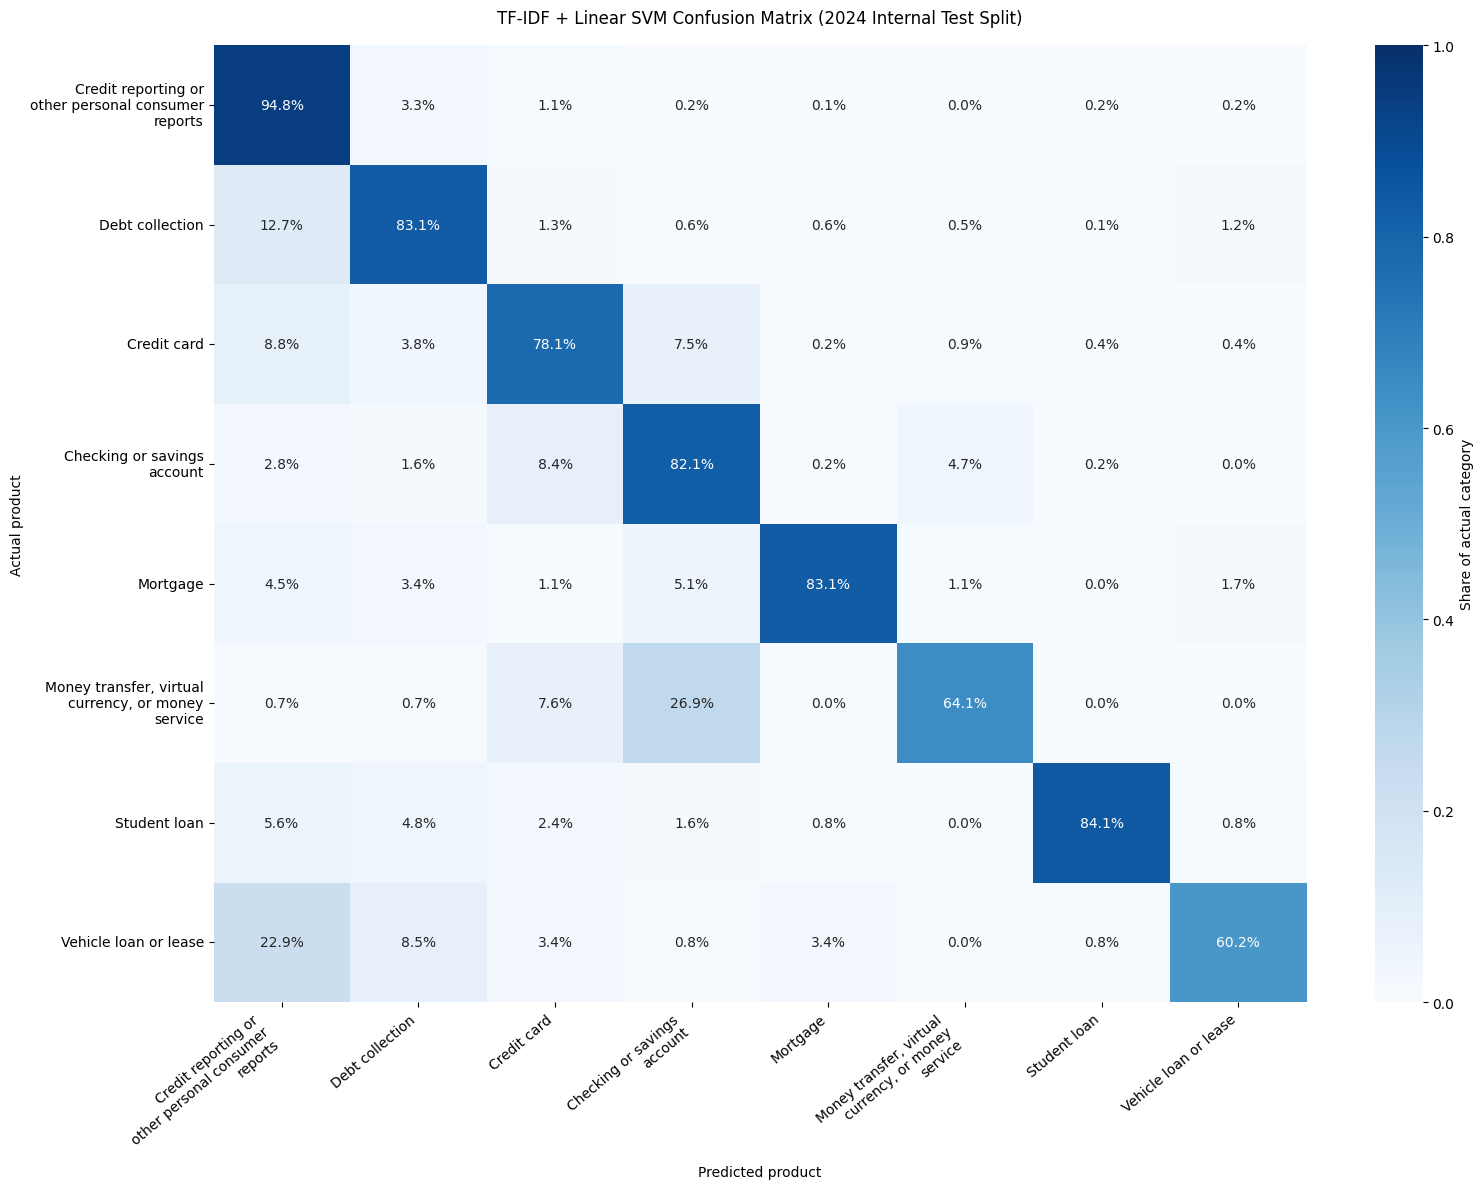

Saved confusion matrix: reports\figures\confusion_matrix.png


In [41]:
wrapped_labels = [textwrap.fill(label, width=24) for label in selected_classes]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    confusion_normalized,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=wrapped_labels,
    yticklabels=wrapped_labels,
    cbar_kws={"label": "Share of actual category"},
    ax=ax,
)
ax.set_title("TF-IDF + Linear SVM Confusion Matrix (2024 Internal Test Split)", pad=16)
ax.set_xlabel("Predicted product")
ax.set_ylabel("Actual product")
ax.tick_params(axis="x", labelrotation=40)
for tick_label in ax.get_xticklabels():
    tick_label.set_horizontalalignment("right")
ax.tick_params(axis="y", labelrotation=0)

# Save the row-normalized matrix as the Week 7 aggregate evaluation visual.
fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix: {CONFUSION_MATRIX_PATH.relative_to(PROJECT_ROOT)}")

In [42]:
# Save the fitted Week 6 selection locally; .gitignore excludes this artifact.
joblib.dump(selected_pipeline, MODEL_PATH, compress=3)
model_size_mb = MODEL_PATH.stat().st_size / (1024 ** 2)

print(f"Saved selected pipeline locally: {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved model size: {model_size_mb:.2f} MB")
print("The local .joblib artifact is excluded by the repository's Git ignore rules.")

Saved selected pipeline locally: models\best_tfidf_classifier.joblib
Saved model size: 3.21 MB
The local .joblib artifact is excluded by the repository's Git ignore rules.


### Week 7 Scope Note

These aggregate outputs use only the existing internal 2024 test split. They do not establish production readiness, 2025 validation, or final project model selection.